- data 폴더 안에 bodyPerformance.csv 파일 로드
- 데이터 중 dtype이 object인 데이터는 LabelEncoding 사용
- 독립 변수, 종속 변수 데이터 분할
- train : test = 8 : 2 비율로 분할
- 독립 데이터들은 StandardScaler를 이용하여 스케일링
- Target의 Class의 개수만큼 Linear 모델에서 아웃풋 출력을 설정하는 모델을 생성
- 손실 함수는 CrossEntropy 사용
- optimizer는 Adam 사용
- 최종 에측값을 이용하여 성능 평가

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df=pd.read_csv('../../data/bodyPerformance.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [3]:
obj_cols=df.select_dtypes('object').columns
obj_cols

Index(['gender', 'class'], dtype='object')

In [4]:
le = LabelEncoder()

for col in obj_cols:
    df[col]=le.fit_transform(df[col])


In [5]:
x=df.drop('class',axis=1)
y=df['class']

X_train,X_test,y_train,y_test= train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
X_train_tensor=torch.tensor(X_train,dtype=torch.float32)
X_test_tensor=torch.tensor(X_test,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.long)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.long)

In [14]:
#모델 정의
class body_clf(nn.Module):
    def __init__(self,_dim):
        super(body_clf, self).__init__()
        self.model=nn.Sequential(
            nn.Linear(_dim, _dim*3),        #직선을 그려준다.
            nn.ReLU(),                      #직선을 33개의 꺽은선으로 변경
            nn.Linear(_dim*3,_dim*2),       
            nn.ReLU(),                      #33개의 직선을 각각 22개씩으로 꺽어준다.
            nn.Linear(_dim*2, 4)
        )
    def forward(self,x):
        return self.model(x)

In [15]:
#모델 생성
body_model = body_clf(X_train_tensor.shape[1])

In [16]:
criterion=nn.CrossEntropyLoss()
#Adam() : 학습률 lr과 관성 momentum을 자동으로 표현한다.
            #Adam에서 lr은 학습률의 최대값을 제한
optimizer=optim.Adam(body_model.parameters(),lr=0.001)

In [17]:
body_model.train()
for epoch in range(200):
    pred=body_model(X_train_tensor)
    loss=criterion(pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) & 30 == 0:
        print(f'Epoch {epoch+1}, Loss : {round(loss.item(),6)}')

Epoch 1, Loss : 1.379809
Epoch 32, Loss : 1.266836
Epoch 33, Loss : 1.262017
Epoch 64, Loss : 1.086091
Epoch 65, Loss : 1.080487
Epoch 96, Loss : 0.945826
Epoch 97, Loss : 0.942628
Epoch 128, Loss : 0.871644
Epoch 129, Loss : 0.87018
Epoch 160, Loss : 0.840426
Epoch 161, Loss : 0.839785
Epoch 192, Loss : 0.822641
Epoch 193, Loss : 0.82213


In [19]:
body_model.eval()
with torch.no_grad():
    pred = body_model(X_test_tensor)
    _, pred_idx = torch.max(pred, 1)
    acc = accuracy_score(y_test_tensor, pred_idx)
    print(f"Test Accuracy: {round(acc, 4)}")
    print(classification_report(y_test_tensor, pred_idx))

Test Accuracy: 0.6439
              precision    recall  f1-score   support

           0       0.65      0.79      0.71       670
           1       0.51      0.47      0.49       669
           2       0.60      0.54      0.57       670
           3       0.81      0.78      0.79       670

    accuracy                           0.64      2679
   macro avg       0.64      0.64      0.64      2679
weighted avg       0.64      0.64      0.64      2679



In [20]:
import matplotlib.pyplot as plt

In [21]:
#선형 모델
linear_model= nn.Sequential(
    nn.Linear(1,16),
    nn.Linear(16,1)
)

In [22]:
#비선형 모델
relu_model = nn.Sequential(
    nn.Linear(1,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

In [23]:
loss=nn.MSELoss()
optimizer_linear=optim.Adam(linear_model.parameters(), lr=0.01)
optimizer_relu=optim.Adam(relu_model.parameters(),lr=0.01)

In [24]:
#sin 데이터 분할
x=torch.linspace(-3,3,200).unsqueeze(1)
y=torch.sin(x)


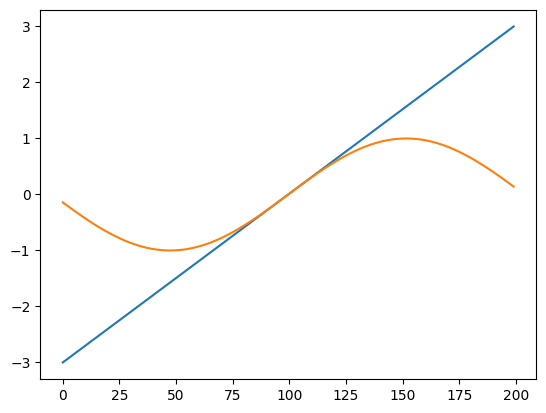

In [25]:
plt.plot(x)
plt.plot(y)
plt.show()

In [26]:
#반복 학습
for epoch in range(3000):
    #선형 모델
    pred1=linear_model(x)
    loss1=loss(pred1, y)
    optimizer_linear.zero_grad()
    loss1.backward()
    optimizer_linear.step()
    #비선형 모델
    pred2=linear_model(x)
    loss2=loss(pred2, y)
    optimizer_relu.zero_grad()
    loss2.backward()
    optimizer_relu.step()

In [27]:
#예측 결과 
#detach() : 예측은 결과는 결과값 + 가중치 함수 데이터가 포함되어있기 때문에 detach()로 결과값만 가져옴
linear_pred=linear_model(x).detach()
relu_pred=relu_model(x).detach()
print(linear_pred)

tensor([[-1.0236],
        [-1.0133],
        [-1.0030],
        [-0.9927],
        [-0.9825],
        [-0.9722],
        [-0.9619],
        [-0.9516],
        [-0.9413],
        [-0.9310],
        [-0.9207],
        [-0.9104],
        [-0.9002],
        [-0.8899],
        [-0.8796],
        [-0.8693],
        [-0.8590],
        [-0.8487],
        [-0.8384],
        [-0.8281],
        [-0.8179],
        [-0.8076],
        [-0.7973],
        [-0.7870],
        [-0.7767],
        [-0.7664],
        [-0.7561],
        [-0.7458],
        [-0.7356],
        [-0.7253],
        [-0.7150],
        [-0.7047],
        [-0.6944],
        [-0.6841],
        [-0.6738],
        [-0.6635],
        [-0.6533],
        [-0.6430],
        [-0.6327],
        [-0.6224],
        [-0.6121],
        [-0.6018],
        [-0.5915],
        [-0.5812],
        [-0.5710],
        [-0.5607],
        [-0.5504],
        [-0.5401],
        [-0.5298],
        [-0.5195],
        [-0.5092],
        [-0.4989],
        [-0.

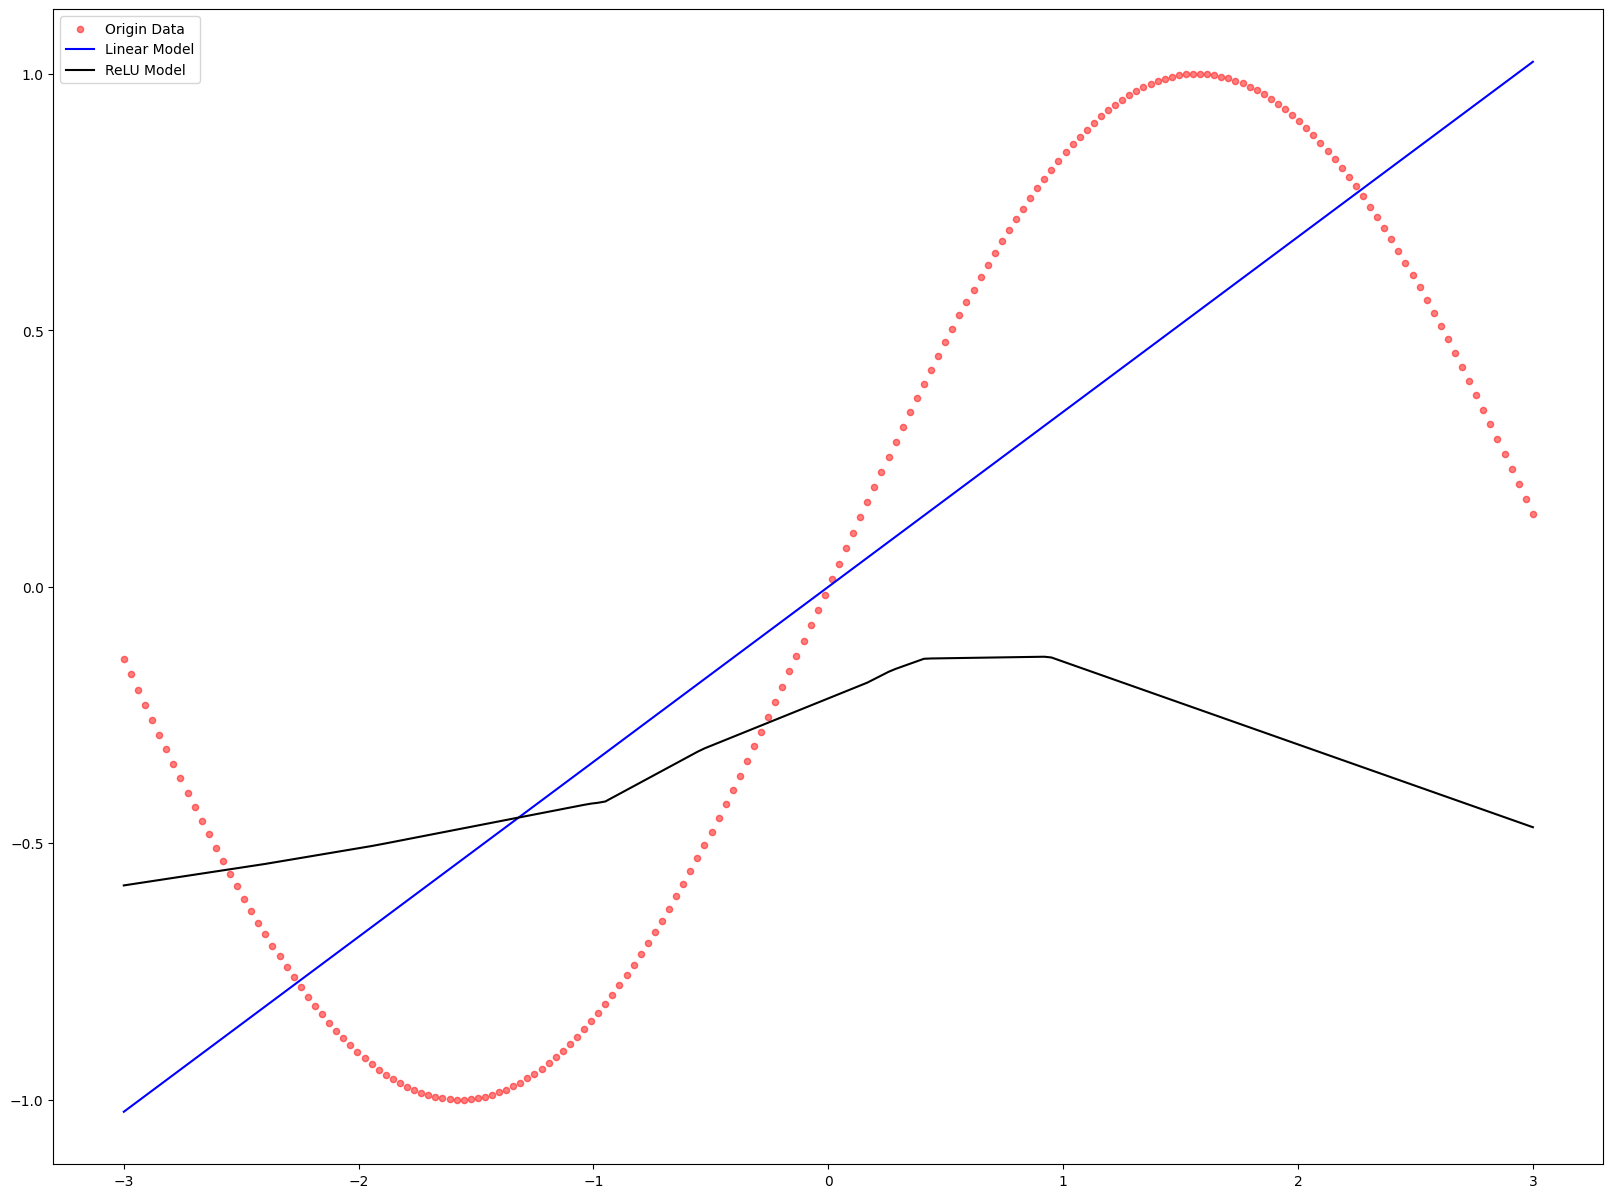

In [28]:
plt.figure(figsize=(20, 15))
# 원본 데이터 산점도 표시 
plt.scatter(x, y, label = 'Origin Data', s = 20, color = 'red', alpha = 0.5)
# 선형 모델 예측 결과를 라인 그래프로 표시 
plt.plot(x, linear_pred, label = 'Linear Model', color = 'blue')
# 비선형 모델의 예측 결과 라인 그래프로 표시 
plt.plot(x, relu_pred, label = 'ReLU Model', color = 'black')

plt.legend()

plt.show()